In [41]:
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
import matplotlib.pyplot as plt # Para gráficas de diagnóstico
import plotly.graph_objects as go

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Para diagnóstico SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [42]:
# Configuración del activo, fechas y reproducibilidad
TICKER = 'AAPL' # Activo de ejemplo (puedes cambiarlo)
RANDOM_SEED = 42 
START_PRED_DATE = '2025-10-20'
END_PRED_DATE = '2025-10-24'
PREDICTION_DAYS = 5

In [43]:
# Fijar semillas
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [ ]:
# Función auxiliar para FFNN (creación de ventanas de rezagos)
def create_sequences(data, n_lag):
    """Convierte la serie de tiempo en un dataset de pares X (lags) e y (siguiente valor)."""
    X, y = [], []
    for i in range(n_lag, len(data)):
        X.append(data[i-n_lag:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [49]:
# Usamos el método Ticker().history() y forzamos el formato para Plotly Express.
end_train_date = pd.to_datetime(START_PRED_DATE) - pd.Timedelta(days=1) 
data = yf.Ticker(TICKER).history(start='2010-01-01', end=end_train_date.strftime('%Y-%m-%d'))

# Creamos el DataFrame 'df' para el modelado
df = data[['Close']].copy()

# Creamos una copia del DF con 'Date' como columna para Plotly Express
df_plot_px = df.reset_index()
df_plot_px.rename(columns={'Close': 'price', 'Date': 'Date'}, inplace=True)
df.index = pd.to_datetime(df.index) # Aseguramos que el DF de modelado use Date como índice

# Generar el índice de fechas para las 5 predicciones (solo días hábiles)
prediction_index = pd.date_range(start=START_PRED_DATE, end=END_PRED_DATE, freq='B')
prediction_index = prediction_index[prediction_index.dayofweek < 5] 

print(f"Última fecha de entrenamiento: {df.index[-1].strftime('%Y-%m-%d')}")

Última fecha de entrenamiento: 2025-10-17


In [50]:
fig = px.line(df_plot_px, x='Date', y='price',
              title=f'Histórico del Precio de Cierre Diario de {TICKER}')

fig.update_traces(line=dict(color='steelblue'))
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Precio (USD)',
    template='plotly_white'
)
fig.show()

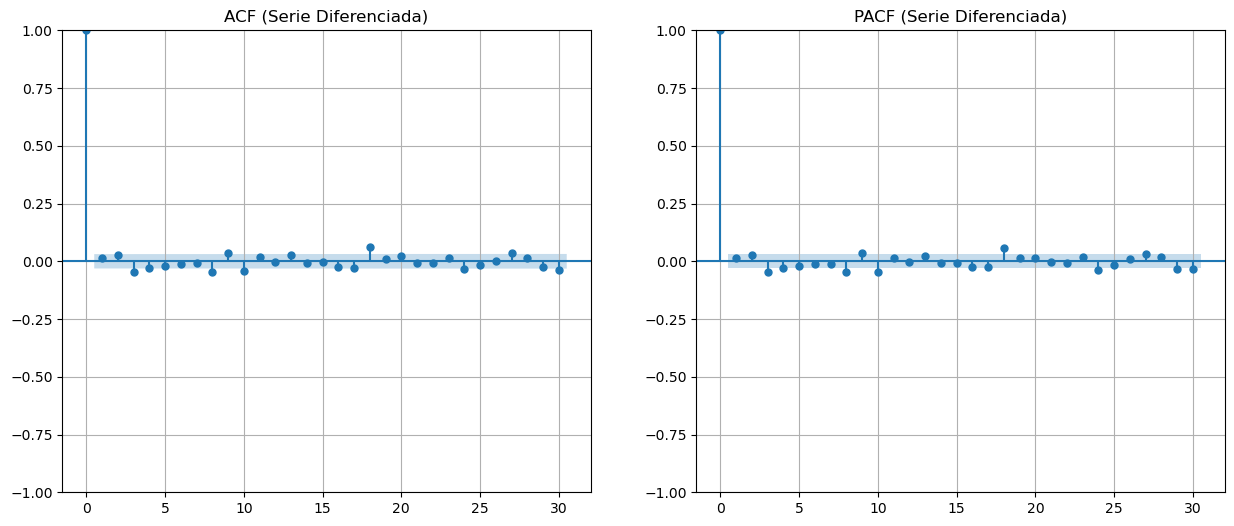

In [52]:
df_sarima = df['Close'].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(df_sarima, lags=30, ax=axes[0], title='ACF (Serie Diferenciada)')
axes[0].grid(True)
plot_pacf(df_sarima, lags=30, ax=axes[1], title='PACF (Serie Diferenciada)')
axes[1].grid(True)
plt.show()

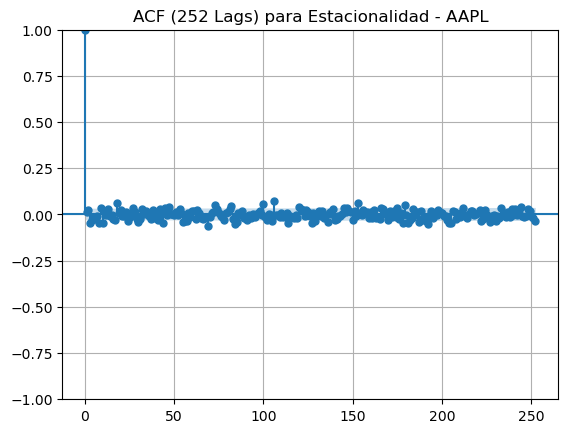

In [53]:
plot_acf(df_sarima, lags=252, title=f'ACF (252 Lags) para Estacionalidad - {TICKER}')
plt.grid(True)
plt.show()

In [54]:
SARIMAX_ORDER = (5, 1, 0)
SARIMAX_SEASONAL_ORDER = (0, 0, 0, 0)

In [55]:
# Entrenamiento y predicción SARIMAX
sarimax_model = SARIMAX(
    df['Close'],
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_results = sarimax_model.fit(disp=False)
sarimax_predictions = sarimax_results.forecast(steps=PREDICTION_DAYS)
sarimax_df = pd.DataFrame(sarimax_predictions.values, index=prediction_index, columns=['pred_close_sarimax'])
sarimax_df.index = [f'{d.year}-{d.month:02d}-{d.day:02d}' for d in sarimax_df.index]

c:\Users\canal\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\canal\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\canal\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

c:\Users\canal\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [57]:
df_plot = df.tail(100).copy()
sarimax_df.index = pd.to_datetime(sarimax_df.index)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['Close'], mode='lines', name='Histórico Reciente', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=sarimax_df.index, y=sarimax_df.iloc[:, 0], mode='lines+markers', name='Predicción SARIMAX', line=dict(color='orange', dash='dash', width=3), marker=dict(size=8)))

fig.update_layout(title=f'Predicción SARIMAX de 5 Días vs. Historial Reciente de {TICKER}', xaxis_title='Fecha', yaxis_title='Precio de Cierre (USD)', template='plotly_white')
fig.show()

### Modelo FFNN

In [58]:
# Definición de Hiperparámetros FFNN
N_LAG = 20
N_EPOCHS = 50
BATCH_SIZE = 32
N_NEURONS = 64

In [59]:
# Preparación y Escalado
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))
X, y = create_sequences(scaled_data, N_LAG)

In [60]:
# Construcción y Entrenamiento FFNN
ffnn_model = Sequential()
ffnn_model.add(Dense(N_NEURONS, activation='relu', input_shape=(N_LAG,))) 
ffnn_model.add(Dense(N_NEURONS // 2, activation='relu'))
ffnn_model.add(Dense(1)) 
ffnn_model.compile(optimizer='adam', loss='mean_squared_error')
ffnn_model.fit(X, y, epochs=N_EPOCHS, batch_size=BATCH_SIZE, verbose=0)

c:\Users\canal\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [62]:
# Generación de Predicciones FFNN
ffnn_predictions_scaled = []
last_n_lag = scaled_data[-N_LAG:].flatten().tolist() 

for i in range(PREDICTION_DAYS):
    current_input = np.array(last_n_lag).reshape(1, N_LAG) 
    predicted_price_scaled = ffnn_model.predict(current_input, verbose=0)[0, 0]
    ffnn_predictions_scaled.append(predicted_price_scaled)
    last_n_lag.pop(0) 
    last_n_lag.append(predicted_price_scaled) 

# Invertir el escalado
ffnn_predictions = scaler.inverse_transform(np.array(ffnn_predictions_scaled).reshape(-1, 1))
ffnn_df = pd.DataFrame(ffnn_predictions, index=prediction_index, columns=['pred_close_ffnn'])
ffnn_df.index = [f'{d.year}-{d.month:02d}-{d.day:02d}' for d in ffnn_df.index]

In [63]:
df_plot = df.tail(100).copy()
ffnn_df.index = pd.to_datetime(ffnn_df.index)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['Close'], mode='lines', name='Histórico Reciente', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=ffnn_df.index, y=ffnn_df.iloc[:, 0], mode='lines+markers', name='Predicción FFNN', line=dict(color='red', dash='dash', width=3), marker=dict(size=8)))

fig.update_layout(title=f'Predicción FFNN de 5 Días vs. Historial Reciente de {TICKER}', xaxis_title='Fecha', yaxis_title='Precio de Cierre (USD)', template='plotly_white')
fig.show()

In [64]:
# Unir las predicciones
sarimax_df.index = pd.to_datetime(sarimax_df.index)
ffnn_df.index = pd.to_datetime(ffnn_df.index)
final_predictions_df = pd.merge(sarimax_df, ffnn_df, left_index=True, right_index=True)
final_predictions_df.index.name = 'date'

In [67]:
final_predictions_df_formatted = final_predictions_df[['pred_close_sarimax', 'pred_close_ffnn']].copy()

In [79]:
# Gráfica final combinada
last_hist_date = df.index[-1]
last_hist_price = df.iloc[-1]['Close']
df_hist_plot = df.tail(60).copy()
df_final = final_predictions_df_formatted.copy()
df_final.index = pd.to_datetime(df_final.index)

fig = go.Figure()

# 1. Histórico Reciente
fig.add_trace(go.Scatter(x=df_hist_plot.index, y=df_hist_plot['Close'], mode='lines', name='Histórico (Datos de Entrenamiento)', line=dict(color='grey', width=1)))

# 2. Conector (Para unir el histórico con las predicciones)
fig.add_trace(go.Scatter(
    x=[last_hist_date] + df_final.index.tolist(), 
    y=[last_hist_price] + df_final['pred_close_sarimax'].tolist(), 
    mode='lines', 
    name='_Predicción SARIMAX_Conector', 
    line=dict(color='orange', dash='dot', width=2), 
    showlegend=False
))

In [80]:
# Predicción SARIMAX y FFNN
fig.add_trace(go.Scatter(x=df_final.index, y=df_final['pred_close_sarimax'], mode='lines+markers', name='Predicción SARIMAX', line=dict(color='orange', dash='dot', width=2), marker=dict(size=8)))
fig.add_trace(go.Scatter(x=df_final.index, y=df_final['pred_close_ffnn'], mode='lines+markers', name='Predicción FFNN', line=dict(color='red', dash='dash', width=2), marker=dict(size=8)))
fig.update_layout(title=f'Predicciones de 5 Días ({TICKER})', xaxis_title='Fecha', yaxis_title='Precio de Cierre (USD)', template='plotly_white')
fig.show()

In [81]:
# Mostrar la tabla de predicciones 
final_predictions_df_formatted.index.name = 'date'
print(final_predictions_df_formatted.to_string(float_format="%.2f"))

            pred_close_sarimax  pred_close_ffnn
date                                           
2025-10-20              252.18           249.02
2025-10-21              252.35           250.34
2025-10-22              252.16           251.54
2025-10-23              252.08           252.30
2025-10-24              251.98           252.13
